<h1> CMBI Coursework 2 -  Part 2
<h3> Giuliano Costa

In [ ]:
"""Imports"""
import numpy as np
from scipy import stats, special
from itertools import combinations
from matplotlib import pyplot as plt
import seaborn as sns


<Axes: ylabel='Count'>

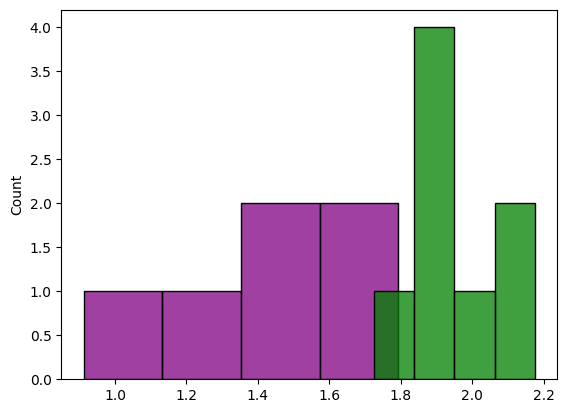

In [ ]:
random_seed = 24225233

samples_1 = stats.norm.rvs(loc=1.5, scale=0.2, random_state=random_seed, size=6)
samples_2 = stats.norm.rvs(loc=2.0, scale=0.2, random_state=random_seed+1, size=8)

sns.histplot(samples_1, color="purple")
sns.histplot(samples_2, color="green")


# 1. Single permutation testing

## a.

In [20]:
original_t_stat, pvalue =  stats.ttest_ind(samples_1, samples_2, random_state=random_seed, equal_var=False)
print("T-statistic: %.10f" % original_t_stat)
print("p-value: %.10f" % pvalue)
print("p-value: %.2e" % pvalue)


T-statistic: -4.0334980564
p-value: 0.0056827342
p-value: 5.68e-03


## b. Permutation based p-value

### i 

In [26]:
D = np.concatenate([samples_1, samples_2])
print(D)

[1.41375869 1.79246329 1.44117927 0.91265544 1.20954837 1.60565228
 1.86868745 2.07823894 1.98055579 1.89140428 1.85236527 2.17485681
 1.72514909 1.94655957]


### ii.

In [28]:
# Find all permutations of group 1 and group 2
n_1, n_2 = 6, 8  # Sizes of the two groups
n = n_1 + n_2    # Total number of samples
D = np.concatenate([samples_1, samples_2])  # Combined data array

# Calculate total number of possible permutations
num_permutations = int(special.comb(n, n_1))

# Initialize array to store all permutations
all_perms = []

# Generate all possible ways to select n_1 elements (for group 1)
for indices in combinations(range(n), n_1):
    # Create permutation by selecting indices
    perm_group1 = [D[i] for i in indices]
    perm_group2 = [D[i] for i in range(n) if i not in indices]
    
    # Store this permutation
    all_perms.append((perm_group1, perm_group2))

print(f'Total number of permutations: {num_permutations}')

Total number of permutations: 3003


In [30]:
N = len(all_perms)
t_statistic_perms = np.zeros(N)
for row in range(N):
    group1_perm = all_perms[row, :n_1]
    group2_perm = all_perms[row, n_1:]
    ttest_perm, _ = stats.ttest_ind(group1_perm, group2_perm)
    t_statistic_perms[row] = ttest_perm

TypeError: list indices must be integers or slices, not tuple

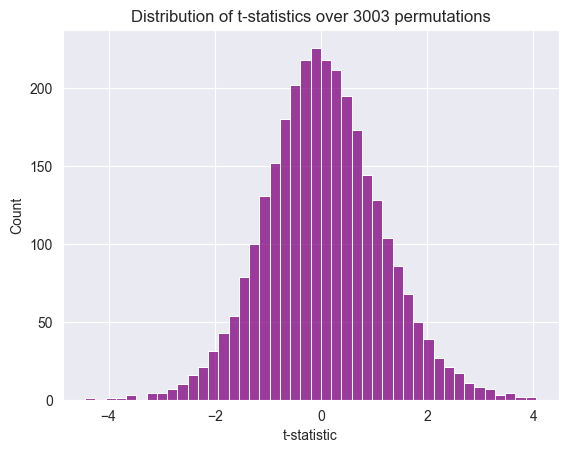

In [9]:
"""Construct empirical distribution for the t-statistics"""
sns.set_style('darkgrid')
ax = sns.histplot(t_stats, color="purple")
ax.set(title="Distribution of t-statistics over 3003 permutations", xlabel='t-statistic', ylabel='Count')
plt.show()



Permutation-based p-value: 0.9997


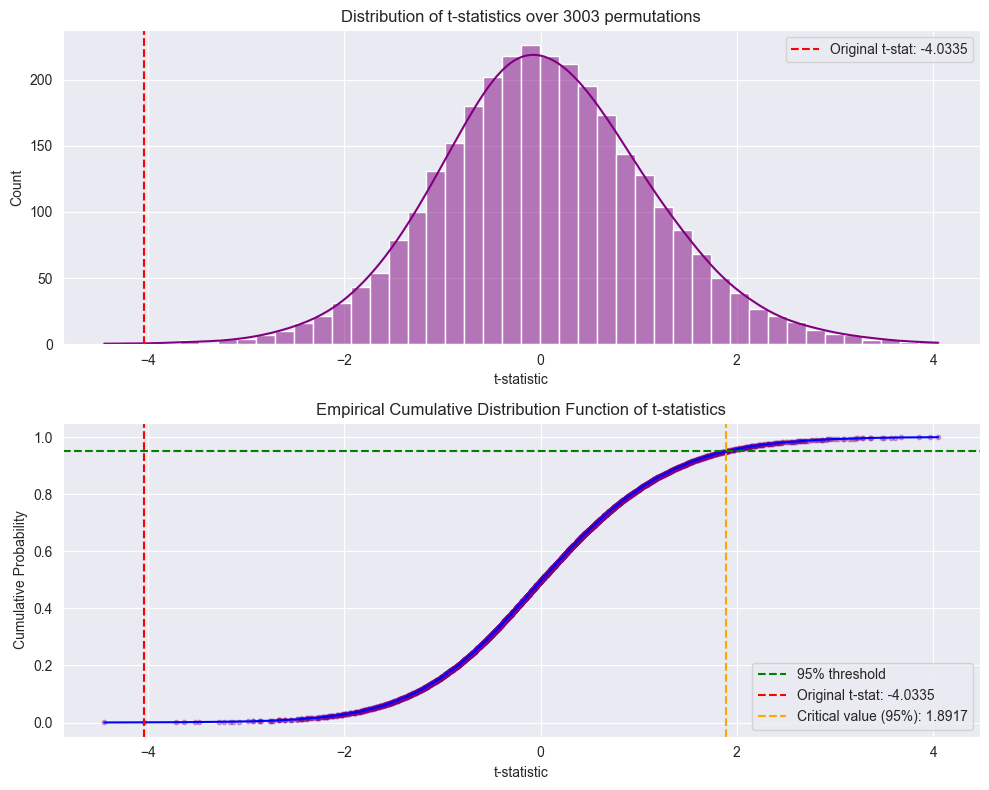

In [10]:
# Calculate ECDF
t_stats_sorted = np.sort(t_stats)
# ecdf = np.arange(1, len(t_stats) + 1) / len(t_stats)


critical_index = int(0.95 * len(t_stats_sorted))
critical_value = t_stats_sorted[critical_index]

# Calculate and print the p-value
p_value = (np.sum(np.array(t_stats) >= original_t_stat)) / len(t_stats)
print(f"Permutation-based p-value: {p_value:.4f}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
sns.histplot(t_stats, color="purple", kde=True)
plt.title("Distribution of t-statistics over 3003 permutations")
plt.xlabel('t-statistic')
plt.ylabel('Count')

plt.axvline(x=original_t_stat, color='red', linestyle='--', 
            label=f'Original t-stat: {original_t_stat:.4f}')
plt.legend()

ecdf_result = stats.ecdf(t_stats)

# Generate x values across the range of t_stats for a smooth curve
x_values = np.linspace(min(t_stats), max(t_stats), 1000)
plt.subplot(2, 1, 2)

# Plot ECDF
plt.plot(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='blue', linewidth=1.5)
plt.scatter(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='purple', alpha=0.3, s=10)

plt.axhline(y=0.95, color='green', linestyle='--', 
            label='95% threshold')
plt.axvline(x=original_t_stat, color='red', linestyle='--', 
            label=f'Original t-stat: {original_t_stat:.4f}')

plt.axvline(x=critical_value, color='orange', linestyle='--', 
            label=f'Critical value (95%): {critical_value:.4f}')
plt.title("Empirical Cumulative Distribution Function of t-statistics")
plt.xlabel('t-statistic')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.tight_layout()
plt.show()


## 1.c)

In [11]:
mean_diff = samples_1.mean() - samples_2.mean()



# 2. Single threshold test

In [12]:
def load_files(filenames):
    n = len(filenames)
    data = np.zeros(shape=(n, 40, 40, 40))
    for im_num, filename in enumerate(filenames):
        with open(filename, 'rb') as f:
            im_data = np.fromfile(f, dtype=np.float32)
            im_data = im_data.reshape((40, 40, 40))
        data[im_num] = im_data
    
    return data

In [13]:
# load all files
filename_CPA_nums = ['4', '5', '6', '7', '8', '9', '10', '11']
filename_PPA_nums = ['3', '6', '9', '10', '13', '14', '15', '16']

filenames_mask = ['./data/wm_mask.img']
filenames_CPA = ['./data/CPA' + num + '_diffeo_fa.img' for num in filename_CPA_nums]
filenames_PPA = ['./data/PPA' + num + '_diffeo_fa.img' for num in filename_PPA_nums]


data_CPA = load_files(filenames_CPA)
data_PPA = load_files(filenames_PPA)
data_mask = load_files(filenames_mask)[0,:,:,:]

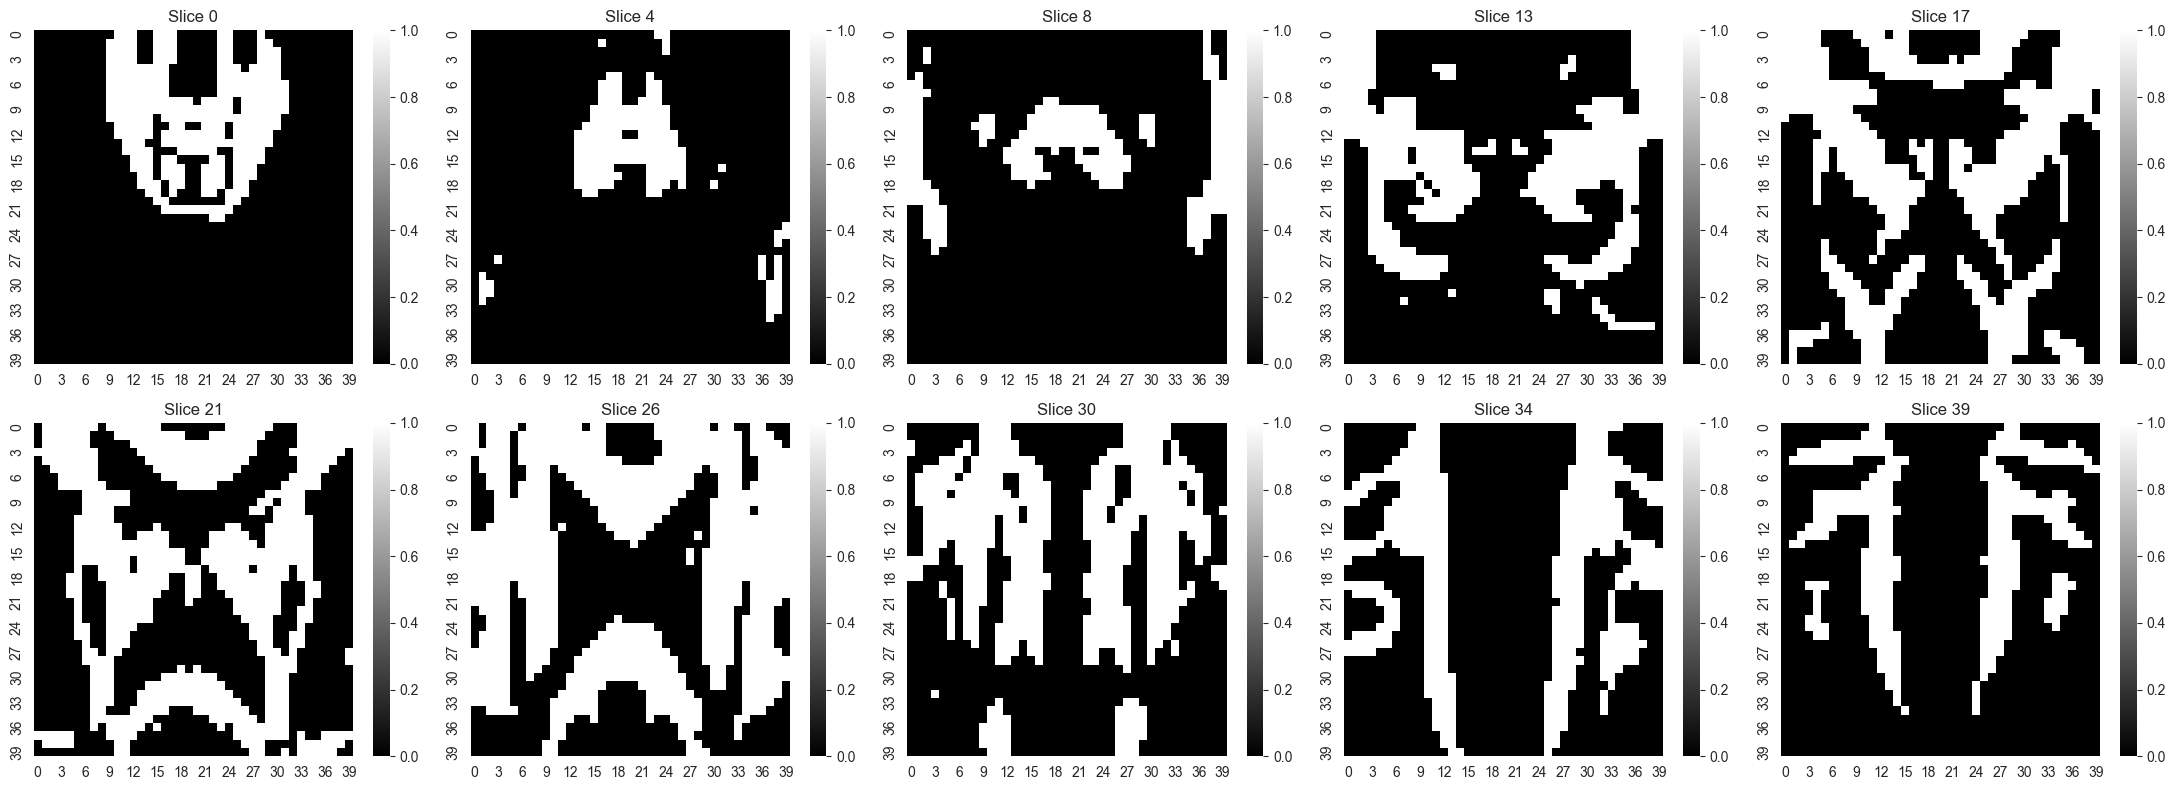

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten() 
slice_indices = np.linspace(0, 39, 10, dtype=int)

for i, idx in enumerate(slice_indices):
    sns.heatmap(data_mask[idx], 
                ax=axes[i], 
                cmap='gray')
    axes[i].set_title(f'Slice {idx}')

plt.tight_layout()
plt.show()

In [15]:
"""Compute t-statistic between the groups"""

print(data_CPA.shape)
print(data_PPA.shape)
print(data_mask.shape)

"""Note, first index in the array is the image num"""

(8, 40, 40, 40)
(8, 40, 40, 40)
(40, 40, 40)


'Note, first index in the array is the image num'

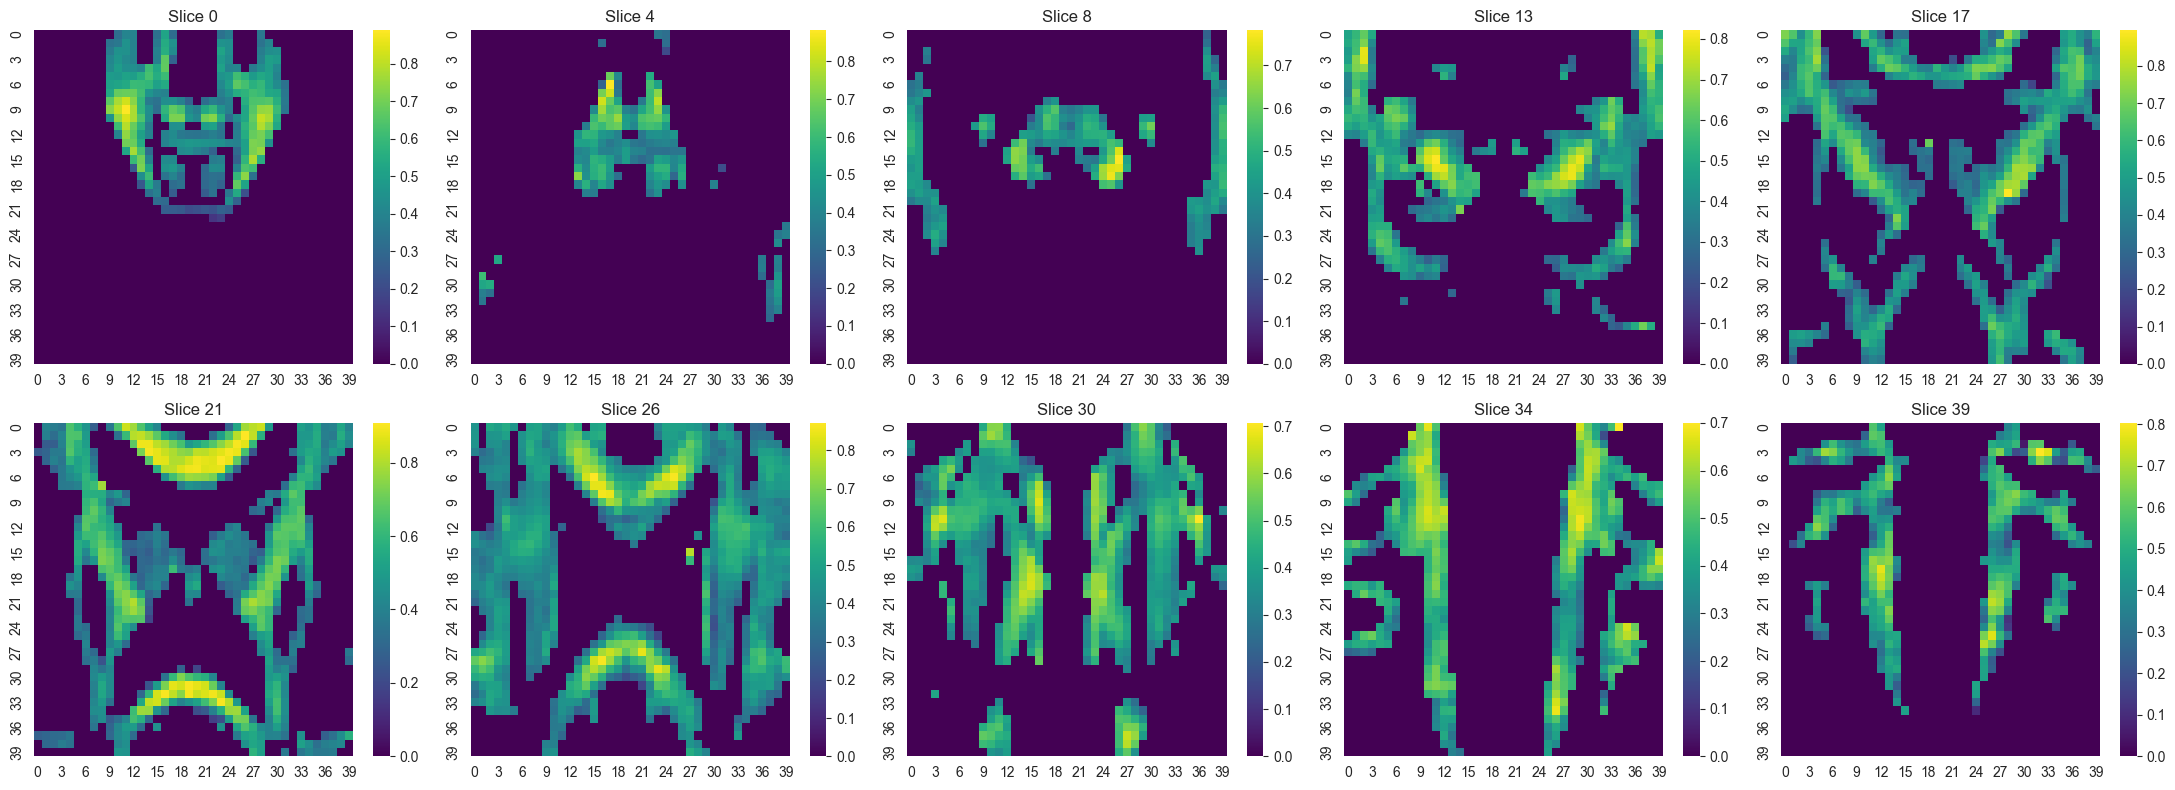

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten() 
slice_indices = np.linspace(0, 39, 10, dtype=int)


for i, idx in enumerate(slice_indices):
    im = data_CPA[0][idx]
    
    slice_ROI = data_mask[idx]
    im_masked = im.copy()
    im_masked[slice_ROI == 0] = 0 
    sns.heatmap(im_masked, 
                ax=axes[i], 
                cmap='viridis')
    axes[i].set_title(f'Slice {idx}')

plt.tight_layout()
plt.show()

## 2.a

Maximum t-statistic among all ROI voxels: 6.5294


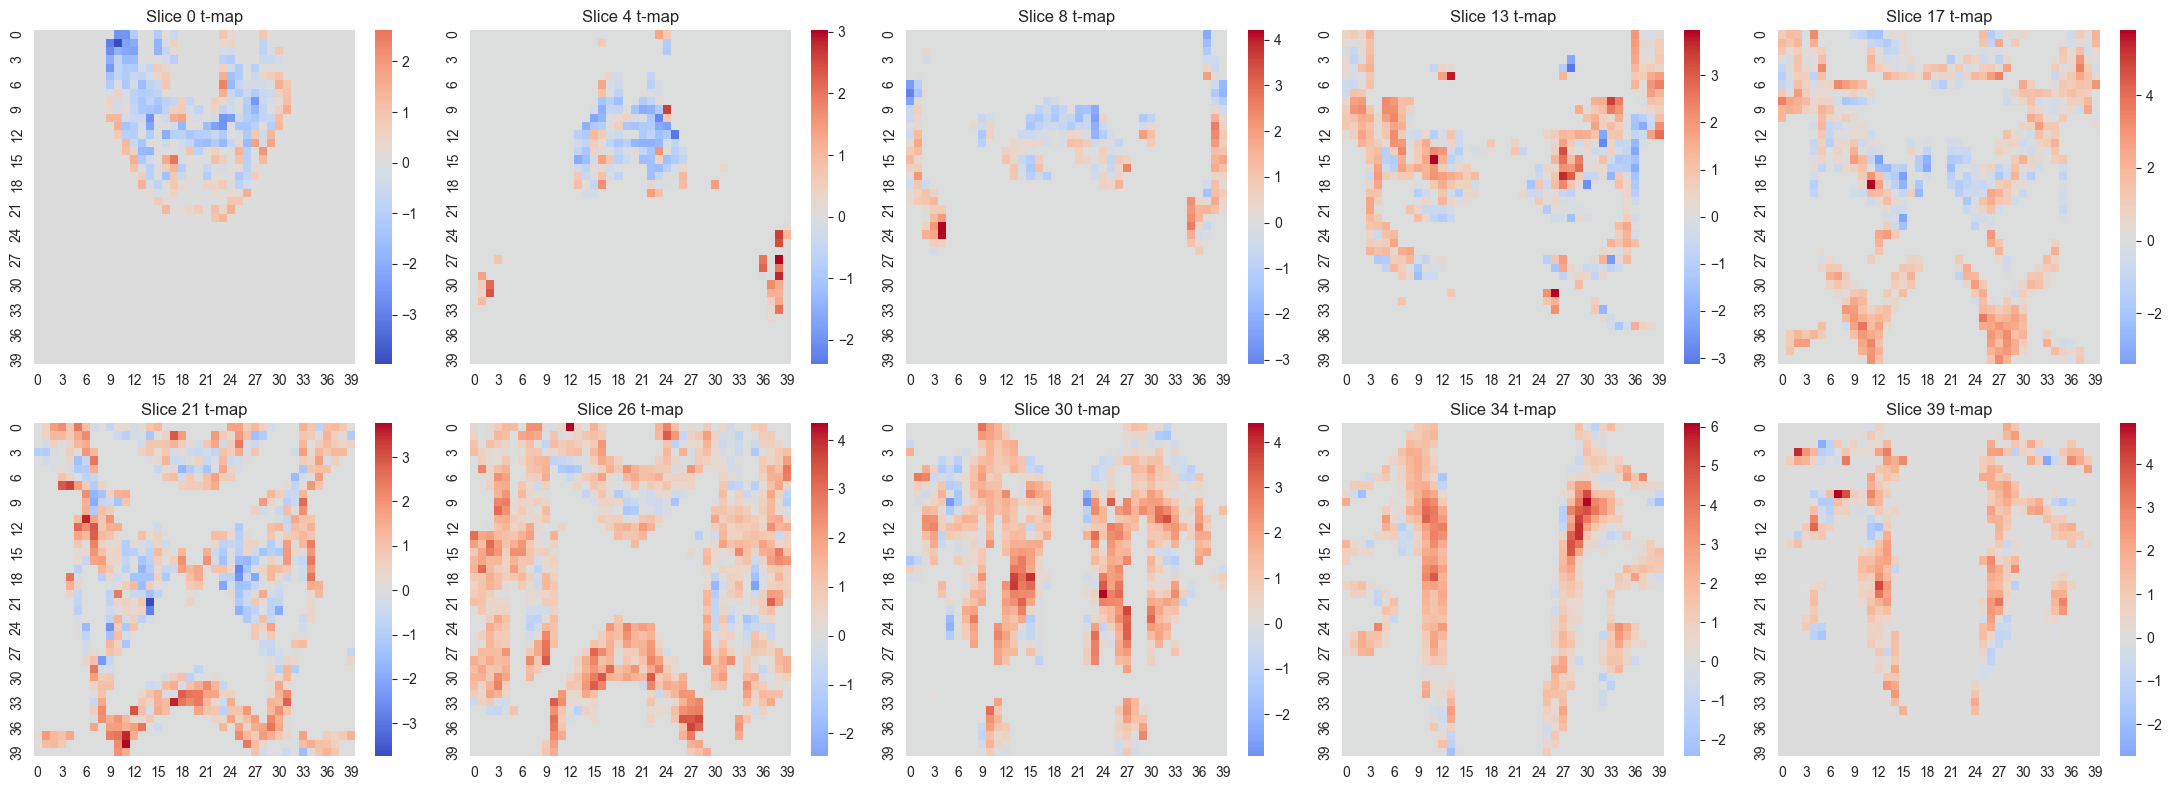

In [17]:
"""GLM Model from part 1 where Y = X₁β₁ + X₂β₂ + e 
Essentially does ttest2.

"""
def compute_tstat_glm(group1_data, group2_data):
    # Combine data
    Y = np.concatenate([group1_data, group2_data])
    
    # Create design matrix
    n1 = len(group1_data)
    n2 = len(group2_data)
    X = np.zeros((n1 + n2, 2))
    X[:n1, 0] = 1  # Group 1 indicator
    X[n1:, 1] = 1  # Group 2 indicator
    
    # Calculate parameter estimates
    XTX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XTX_inv @ (X.T @ Y)
    
    # Calculate residuals and error variance
    Y_hat = X @ beta_hat
    e_hat = Y - Y_hat
    sigma_squared = (e_hat.T @ e_hat) / (n1 + n2 - 2)
    
    # Calculate parameter covariance
    cov_beta = sigma_squared * XTX_inv
    
    # Define contrast vector for group difference
    lambda_vec = np.array([1, -1])  # Test β₁ - β₂
    
    # Calculate t-statistic
    lambda_beta = lambda_vec @ beta_hat
    lambda_S_lambda = lambda_vec @ cov_beta @ lambda_vec
    t_stat = lambda_beta / np.sqrt(lambda_S_lambda)
    
    return t_stat

# Create empty array to store t-statistics for all voxels in the ROI
# Get the coordinates of non-zero voxels in the mask
mask_indices = np.where(data_mask > 0)
num_roi_voxels = len(mask_indices[0])
t_map = np.zeros_like(data_mask)

# For each voxel in the ROI
for i, j, k in zip(mask_indices[0], mask_indices[1], mask_indices[2]):
    # Extract the values for this voxel across all subjects in each group
    voxel_vals_CPA = data_CPA[:, i, j, k]  # 8 subjects in group 1
    voxel_vals_PPA = data_PPA[:, i, j, k]  # 8 subjects in group 2
    
    # Compute t-statistic using our GLM function
    t_stat = compute_tstat_glm(voxel_vals_CPA, voxel_vals_PPA)
    
    # Store the t-statistic in our map
    t_map[i, j, k] = t_stat

# Find the maximum t-statistic among all voxels in the ROI
max_t_stat = np.max(t_map[data_mask > 0])
print(f"Maximum t-statistic among all ROI voxels: {max_t_stat:.4f}")

# Optional: Visualize the t-map
import matplotlib.pyplot as plt
import seaborn as sns

# Display t-map for a few slices
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
slice_indices = np.linspace(0, 39, 10, dtype=int)

for i, idx in enumerate(slice_indices):
    # Apply mask to t-map
    t_slice = t_map[idx].copy()
    mask_slice = data_mask[idx]
    t_slice[mask_slice == 0] = 0
    
    sns.heatmap(t_slice, 
                ax=axes[i], 
                cmap='coolwarm',
                center=0)  # Center colormap at 0
    axes[i].set_title(f'Slice {idx} t-map')

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from scipy import stats, special
from itertools import combinations
import time

# First, define our GLM t-statistic function (this is the same as before)
def compute_tstat_glm(group1_data, group2_data):
    # Combine data
    Y = np.concatenate([group1_data, group2_data])
    
    # Create design matrix
    n1 = len(group1_data)
    n2 = len(group2_data)
    X = np.zeros((n1 + n2, 2))
    X[:n1, 0] = 1  # Group 1 indicator
    X[n1:, 1] = 1  # Group 2 indicator
    
    # Calculate parameter estimates
    XTX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XTX_inv @ (X.T @ Y)
    
    # Calculate residuals and error variance
    Y_hat = X @ beta_hat
    e_hat = Y - Y_hat
    sigma_squared = (e_hat.T @ e_hat) / (n1 + n2 - 2)
    
    # Calculate parameter covariance
    cov_beta = sigma_squared * XTX_inv
    
    # Define contrast vector for group difference
    lambda_vec = np.array([1, -1])  # Test β₁ - β₂
    
    # Calculate t-statistic
    lambda_beta = lambda_vec @ beta_hat
    lambda_S_lambda = lambda_vec @ cov_beta @ lambda_vec
    t_stat = lambda_beta / np.sqrt(lambda_S_lambda)
    
    return t_stat

# Function to compute t-map and max t-statistic for a given grouping
def compute_tmap_and_max(data1, data2, mask):
    t_map = np.zeros_like(mask, dtype=float)
    mask_indices = np.where(mask > 0)
    
    for i, j, k in zip(mask_indices[0], mask_indices[1], mask_indices[2]):
        # Extract voxel values for both groups
        voxel_vals_1 = data1[:, i, j, k]
        voxel_vals_2 = data2[:, i, j, k]
        
        # Compute t-statistic
        t_stat = compute_tstat_glm(voxel_vals_1, voxel_vals_2)
        t_map[i, j, k] = t_stat
    
    # Find max t-statistic in the ROI
    max_t = np.max(t_map[mask > 0])
    return max_t, t_map

# Get dimensions and counts
n_CPA = data_CPA.shape[0]  # Number of subjects in group 1
n_PPA = data_PPA.shape[0]  # Number of subjects in group 2
n_total = n_CPA + n_PPA    # Total number of subjects

# Compute actual (unpermuted) maximum t-statistic
original_max_t, original_tmap = compute_tmap_and_max(data_CPA, data_PPA, data_mask)
print(f"Original maximum t-statistic: {original_max_t:.4f}")

# Combine all subjects into one array for permutation
all_data = np.concatenate([data_CPA, data_PPA], axis=0)

# Calculate total number of possible permutations
n_permutations = int(special.comb(n_total, n_CPA))
print(f"Total possible permutations: {n_permutations}")

# If there are too many permutations, we can use a subset
max_permutations = min(n_permutations, 100)  # Limiting to 1000 for computational feasibility
print(f"Using {max_permutations} permutations")

# Generate all combinations of subject indices for the first group
all_combinations = list(combinations(range(n_total), n_CPA))

# If we're using a subset, randomly sample from all combinations
if len(all_combinations) > max_permutations:
    import random
    random.seed(24225233)  # Use your student ID as random seed
    all_combinations = random.sample(all_combinations, max_permutations)

# Always include the original labeling
original_combination = tuple(range(n_CPA))
if original_combination not in all_combinations:
    all_combinations[0] = original_combination

# Compute max t-statistic for each permutation
max_t_stats = []
print("Starting permutation testing...")
start_time = time.time()

for i, combo in enumerate(all_combinations):
    if i % 10 == 0:  # Progress update
        print(f"Processing permutation {i+1}/{len(all_combinations)}")
    
    # Indices for group 1
    idx_group1 = list(combo)
    
    # Indices for group 2 (all indices not in group 1)
    idx_group2 = [i for i in range(n_total) if i not in idx_group1]
    
    # Get the data for each group in this permutation
    perm_data1 = all_data[idx_group1]
    perm_data2 = all_data[idx_group2]
    
    # Compute max t-statistic for this permutation
    max_t, _ = compute_tmap_and_max(perm_data1, perm_data2, data_mask)
    max_t_stats.append(max_t)

elapsed_time = time.time() - start_time
print(f"Permutation testing completed in {elapsed_time:.2f} seconds")

# Calculate p-value
p_value = (np.sum(np.array(max_t_stats) >= original_max_t)) / len(max_t_stats)
print(f"Permutation-based p-value: {p_value:.4f}")

# Visualize the distribution of max t-statistics
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(max_t_stats, kde=True)
plt.axvline(x=original_max_t, color='red', linestyle='--', 
            label=f'Original max t-stat: {original_max_t:.4f}')
plt.title("Distribution of Maximum t-statistics across Permutations")
plt.xlabel('Maximum t-statistic')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

Original maximum t-statistic: 6.5294
Total possible permutations: 12870
Using 100 permutations
Starting permutation testing...
Processing permutation 1/100


KeyboardInterrupt: 